# Pertemuan 5 – Visualisasi Data

Nama : Lady Kimiel

NIM : 240401010122

Kelas : IF401

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

df = sns.load_dataset('tips')

print("Shape:", df.shape)
print(df.head())
print(df.describe().round(2))

Shape: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


## Langkah 1 – Load & Inspect Dataset

Dataset Tips berhasil dimuat menggunakan library Seaborn. Pada tahap ini dilakukan pengecekan jumlah data, tipe data, serta ringkasan statistik untuk memahami karakteristik dataset sebelum dilakukan visualisasi.

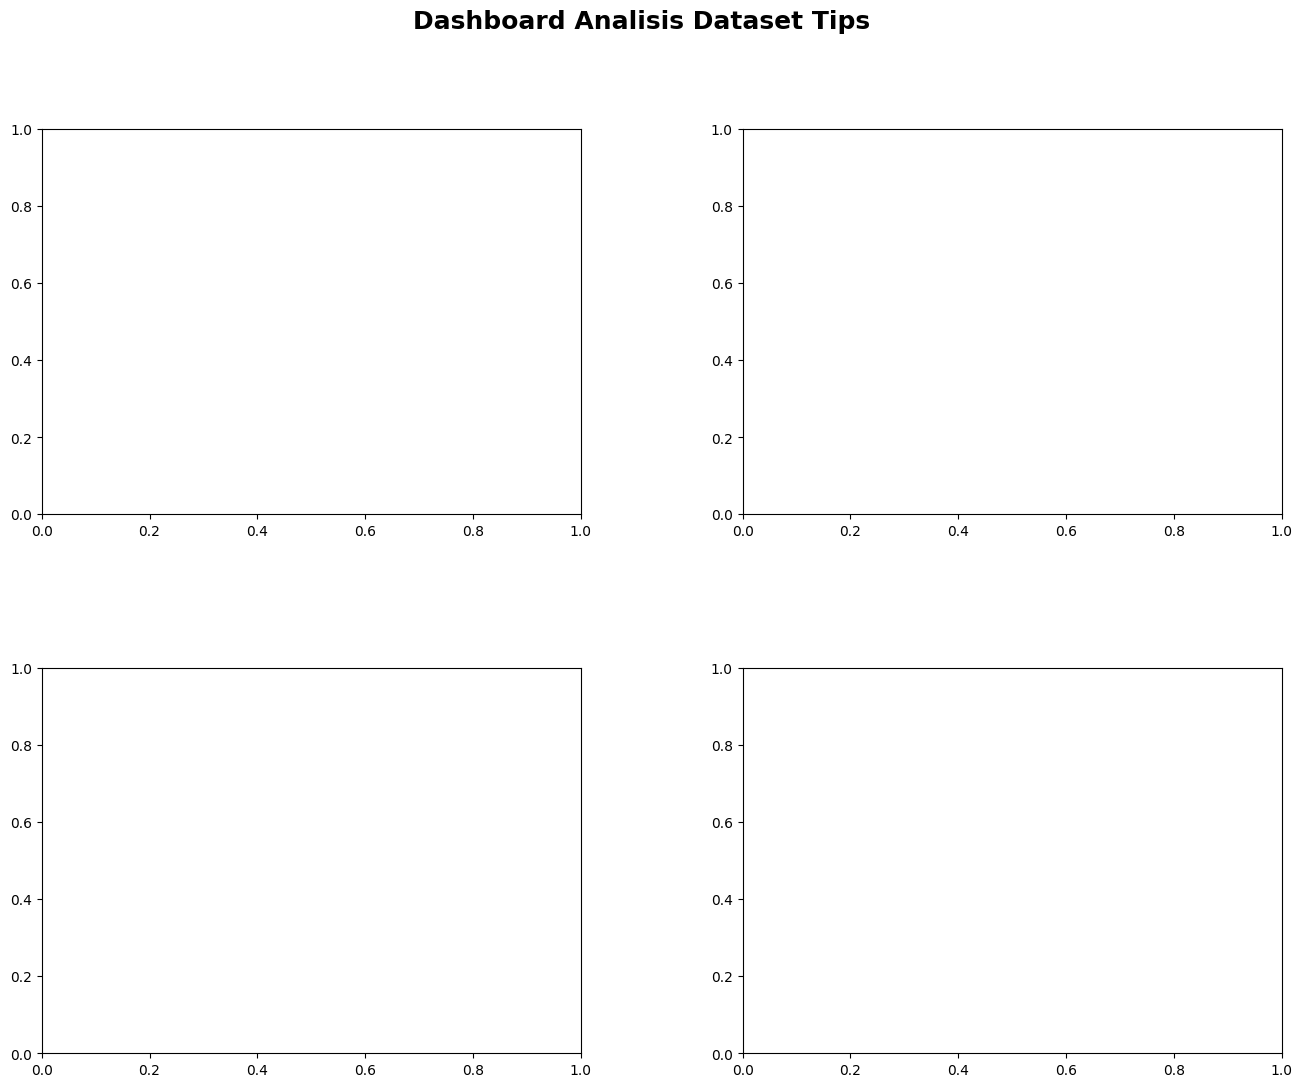

In [2]:
fig = plt.figure(figsize=(16,12))

fig.suptitle(
    "Dashboard Analisis Dataset Tips",
    fontsize=18,
    fontweight='bold'
)

gs = gridspec.GridSpec(
    2,2,
    figure=fig,
    hspace=0.4,
    wspace=0.3
)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])

## Langkah 2 – Setup Dashboard

Membuat layout dashboard menggunakan GridSpec dengan empat area visualisasi. Setiap area akan digunakan untuk menampilkan grafik yang berbeda agar analisis data lebih mudah dipahami.

In [3]:
avg_by_day = df.groupby('day')['total_bill'].mean()

avg_by_day.plot(
    kind='bar',
    ax=ax1,
    color='skyblue'
)

ax1.set_title("Rata-rata Total Bill per Hari")

/tmp/ipykernel_4223/2891431610.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


Text(0.5, 1.0, 'Rata-rata Total Bill per Hari')

## Langkah 3 – Bar Chart

Bar chart digunakan untuk melihat rata-rata total tagihan pelanggan pada setiap hari. Grafik ini membantu mengidentifikasi hari dengan rata-rata transaksi tertinggi dan terendah.

In [4]:
sns.histplot(
    data=df,
    x='total_bill',
    kde=True,
    ax=ax2
)

ax2.set_title("Distribusi Total Bill")

Text(0.5, 1.0, 'Distribusi Total Bill')

## Langkah 4 – Histogram + KDE

Histogram digunakan untuk melihat distribusi total bill pelanggan. Kurva KDE ditambahkan untuk memperlihatkan pola distribusi data secara lebih halus.

In [5]:
sns.boxplot(
    data=df,
    x='day',
    y='total_bill',
    ax=ax3
)

ax3.set_title("Distribusi Total Bill per Hari")

Text(0.5, 1.0, 'Distribusi Total Bill per Hari')

## Langkah 5 – Boxplot

Boxplot digunakan untuk melihat penyebaran data total bill pada setiap hari sekaligus mendeteksi kemungkinan adanya outlier.

In [6]:
sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    ax=ax4
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='red',
    ax=ax4
)

ax4.set_title("Hubungan Total Bill dan Tip")

Text(0.5, 1.0, 'Hubungan Total Bill dan Tip')

## Langkah 6 – Scatter Plot

Scatter plot digunakan untuk melihat hubungan antara total bill dan tip pelanggan. Garis regresi ditambahkan untuk memperjelas arah hubungan kedua variabel tersebut.

In [7]:
plt.savefig(
    "dashboard_tips.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Dashboard berhasil disimpan")

<Figure size 640x480 with 0 Axes>

Dashboard berhasil disimpan


## Kesimpulan

Dashboard visualisasi menunjukkan bahwa nilai total bill pelanggan bervariasi pada setiap hari. Distribusi data didominasi oleh transaksi bernilai menengah dengan beberapa transaksi bernilai tinggi. Selain itu, terdapat hubungan positif antara total bill dan tip, yang menunjukkan bahwa pelanggan cenderung memberikan tip lebih besar ketika nilai tagihan meningkat.